### Wczytanie i analiza pliku dicom

In [ ]:
import pydicom

# Replace with your DICOM file path
file_path = "C:\\Users\\kam45x\\OneDrive - Politechnika Warszawska\\przekroje\\37280977 19\\S2020\\I10"

# Read the DICOM file
ds = pydicom.dcmread(file_path)

print(f"SOP Class UID= {ds.SOPClassUID.name}")
print(f"Image type= {ds.ImageType}")
print(f"Image size= {ds.Rows} x {ds.Columns}")

try:
    print(f"Pixel Spacing= {ds.PixelSpacing}")
except AttributeError:
    print("Pixel Spacing not found in DICOM metadata.")

print(f"Bits stored= {ds.BitsStored}")
print(f"Pixel representation= {ds.PixelRepresentation}")
print(f"Reconstruction diameter= {ds.ReconstructionDiameter}")

try:
    print(f"Rescale Intercept= {ds.RescaleIntercept}")
except AttributeError:
    print("Rescale Intercept not found in DICOM metadata.")

try:
    print(f"Rescale Slope= {ds.RescaleSlope}")
except AttributeError:
    print("Rescale Slope not found in DICOM metadata.")

SOP Class UID= CT Image Storage
Image type= ORIGINAL
Image size= 512 x 512
Pixel Spacing= [0.4921875, 0.4921875]
Bits stored= 12
Pixel representation= 0
Reconstruction diameter= 252
Rescale Intercept= -1024
Rescale Slope= 1


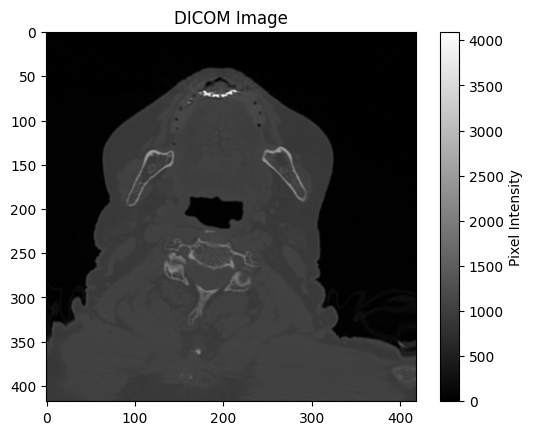

In [11]:
import matplotlib.pyplot as plt

# Convert pixel data to a NumPy array
pixel_array = ds.pixel_array

plt.imshow(pixel_array, cmap='gray')
plt.title("DICOM Image")
plt.colorbar(label='Pixel Intensity')
plt.show()

Maximum pixel value: 2627.0
Minimum pixel value: 0.0


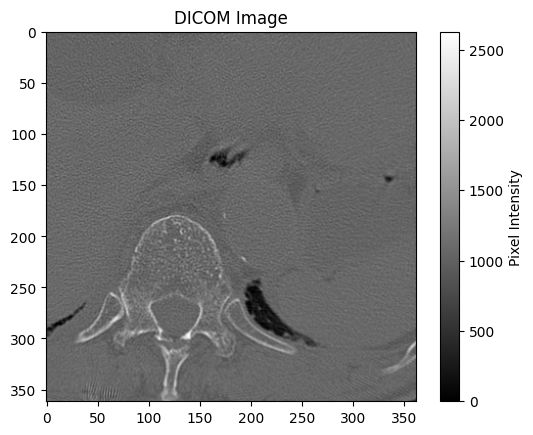

In [6]:
import numpy as np

cropped_array = pixel_array[75:-75, 75:-75].astype(np.float32)

print("Maximum pixel value:", np.max(cropped_array))
print("Minimum pixel value:", np.min(cropped_array))

plt.imshow(cropped_array, cmap='gray')
plt.title("DICOM Image")
plt.colorbar(label='Pixel Intensity')
plt.show()

### Porówanie dwóch obrazów z dicom

Maximum difference value: 407.0
Average difference value: 25.72472


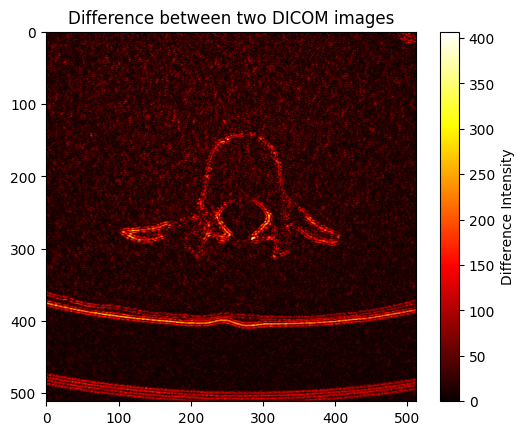

In [7]:
path1 = "C:\\Users\\kam45x\\OneDrive - Politechnika Warszawska\\przekroje\\37262914 7\\DICOM\\S62640\\S2010\\I10"
path2 = "C:\\Users\\kam45x\\OneDrive - Politechnika Warszawska\\przekroje\\37262914 7\\DICOM\\S62640\\S2020\\I10"

array1 = pydicom.dcmread(path1).pixel_array.astype(np.float32)
array2 = pydicom.dcmread(path2).pixel_array.astype(np.float32)

difference = np.abs(array1.astype(np.float32) - array2.astype(np.float32))

print("Maximum difference value:", np.max(difference))
print("Average difference value:", np.mean(difference))

plt.imshow(difference, cmap='hot')
plt.title("Difference between two DICOM images")
plt.colorbar(label='Difference Intensity')
plt.show()